# Gathering requirements

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

for gpu in tf.config.list_physical_devices('GPU'):
    print(tf.config.experimental.get_device_details(gpu))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{'device_name': 'NVIDIA GeForce MX450', 'compute_capability': (7, 5)}


In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [2]:
ds = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\Raze\projects\p3\Dataset", image_size=(256,256), batch_size=32, shuffle=True, seed=42,
)

Found 16011 files belonging to 10 classes.
Using 8006 files for training.


In [3]:
classes=ds.class_names
n_classes=len(classes)
classes

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

# Data spliting-train/val/test

In [6]:
def get_data_partitions(ds,train_split=0.8 ,val_split=0.1,test_split=0.1,shuffle=True ,shuffle_size=10000):
    ds_size=len(ds)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    if shuffle:ds=ds.shuffle(shuffle_size,seed=12)
    
    train_ds=ds.take(train_size) 
    test_ds=ds.skip(train_size)
    val_ds=test_ds.take(val_size) 
    test_ds=test_ds.skip(val_size)
    return train_ds,val_ds, test_ds

train_ds,val_ds, test_ds=get_data_partitions(ds)

# AUTOTUNE

In [7]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# RESIZING & SCALING

In [8]:
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(256, 256),
    tf.keras.layers.Rescaling(1./255)
])
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# CNN Build

In [9]:
model=models.Sequential([
    resize_rescale,
    data_augmentation,
    # CNN backbone
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',input_shape=(32,256,256,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    # Flatten + Dense layers for classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')
])
# watch 23-DL aggain
model.build(input_shape=(32,256,256,3))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

# CNN Compile

In [10]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    ),

    ModelCheckpoint(
    "best_model.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True   # <-- avoids to_json() entirely
)

]

In [12]:
history =model.fit(train_ds, validation_data=val_ds, epochs=15,
          callbacks=callbacks)


Epoch 1/15
200/200 [==============================] - 196s 856ms/step - loss: 1.9246 - accuracy: 0.3037 - val_loss: 1.7293 - val_accuracy: 0.4150 - lr: 0.0010
Epoch 2/15
200/200 [==============================] - 158s 785ms/step - loss: 1.4959 - accuracy: 0.4732 - val_loss: 1.8616 - val_accuracy: 0.4275 - lr: 0.0010
Epoch 3/15
200/200 [==============================] - 180s 901ms/step - loss: 1.1263 - accuracy: 0.6101 - val_loss: 1.5770 - val_accuracy: 0.5100 - lr: 0.0010
Epoch 4/15
200/200 [==============================] - 218s 1s/step - loss: 0.9247 - accuracy: 0.6801 - val_loss: 1.6688 - val_accuracy: 0.5638 - lr: 0.0010
Epoch 5/15
200/200 [==============================] - 1662s 8s/step - loss: 0.7708 - accuracy: 0.7298 - val_loss: 1.3018 - val_accuracy: 0.6263 - lr: 0.0010
Epoch 6/15
200/200 [==============================] - 145s 725ms/step - loss: 0.6805 - accuracy: 0.7559 - val_loss: 1.0695 - val_accuracy: 0.6450 - lr: 0.0010
Epoch 7/15
200/200 [==============================]

In [14]:
model_version=1
model.save(f"C:/Users/Raze/projects/p3/models/{model_version}")

INFO:tensorflow:Assets written to: C:/Users/Raze/projects/p3/models/1\assets


INFO:tensorflow:Assets written to: C:/Users/Raze/projects/p3/models/1\assets


# Prediction

In [20]:
import numpy as np
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(image_batch[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    pred=model.predict(img_array)
    pred_class=classes[np.argmax(pred[0])]
    confidence=round(100*(np.max(pred[0])),2)
    return pred_class,confidence
    

1/1 [==============================] - 0s 35ms/step


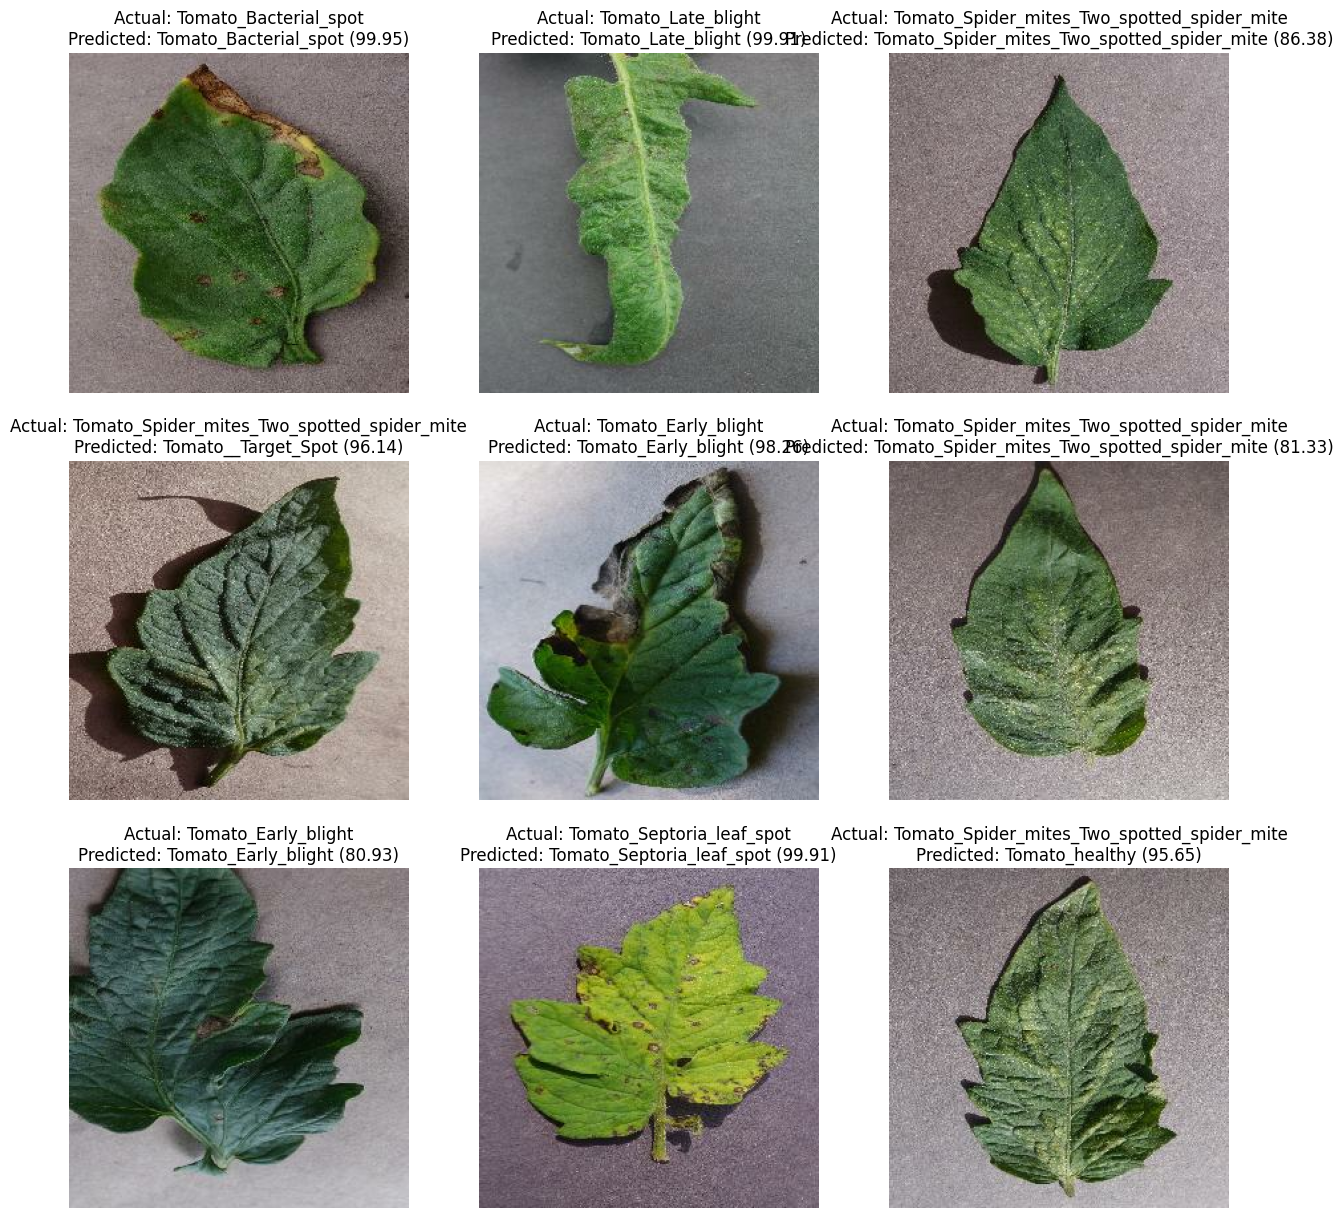

In [21]:
plt.figure(figsize=(15,15))
for image_batch, label_batch in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, image_batch[i].numpy())
        actual_label = classes[label_batch[i].numpy()]

        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_class} ({confidence:.2f})")
        plt.axis("off")


In [22]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

26/26 [==============================] - 3s 91ms/step - loss: 0.5936 - accuracy: 0.8089
Test loss: 0.5936
Test accuracy: 0.8089
